# Speech / Music / Distress Classifier — YAMNet Transfer Learning Baseline

This notebook trains a quick baseline classifier on top of a frozen, pretrained
**YAMNet** model. YAMNet was trained on the full AudioSet ontology, so its
1,024-dimensional embeddings already encode a lot of what makes speech sound
like speech, music sound like music, and screaming sound like screaming — we
just need to train a small head on top of those embeddings using our own
`speech` / `music` / `distress` / `other` labels.

**Scope note:** this YAMNet-based model is a fast way to validate your data
and labeling scheme — it is *not* what will run on the ESP32. YAMNet itself is
a few megabytes, well past the microcontroller's budget. Once this baseline
confirms the data and classes are sound, the next step is training a much
smaller CNN from scratch (or distilling from this model) for the actual
embedded deployment.

In [2]:
!pip install tensorflow-hub

In [1]:
# If you don't have these yet:
# pip install tensorflow_hub scikit-learn matplotlib pandas

import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

I0000 00:00:1786172099.749985   73524 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/josh/RATML/RATML_Hackathon/tf-env/lib/python3.12/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


TensorFlow version: 2.21.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
MANIFEST_PATH = 'audioset_subset/manifest.csv'  # adjust if your path differs

manifest_df = pd.read_csv(MANIFEST_PATH)
print(manifest_df.shape)
manifest_df.head()

(3265, 4)


,filepath,label,split,video_id
0,audioset_subset/train/speech/--PJHxphWEs.wav,speech,train,--PJHxphWEs
1,audioset_subset/train/speech/--aE2O5G5WE.wav,speech,train,--aE2O5G5WE
2,audioset_subset/train/other/--cB2ZVjpnA.wav,other,train,--cB2ZVjpnA
3,audioset_subset/train/other/--aaILOrkII.wav,other,train,--aaILOrkII
4,audioset_subset/train/music/-0DLPzsiXXE.wav,music,train,-0DLPzsiXXE


In [3]:
# Class balance per split - distress will almost certainly be the smallest
print(manifest_df.groupby(['split', 'label']).size().unstack(fill_value=0))

label  distress  music  other  speech
split                                
test        130    500    500     500
train       135    500    500     500


In [4]:
CLASS_NAMES = ['speech', 'music', 'distress', 'other']
label2id = {name: i for i, name in enumerate(CLASS_NAMES)}
id2label = {i: name for name, i in label2id.items()}

train_df = manifest_df[manifest_df['split'] == 'train'].reset_index(drop=True)
test_df = manifest_df[manifest_df['split'] == 'test'].reset_index(drop=True)

print(f'train clips: {len(train_df)}, test clips: {len(test_df)}')

train clips: 1635, test clips: 1630


## Load YAMNet

Loading a model from TensorFlow Hub is a one-liner. The link still resolves
fine even though the TF Hub site itself now redirects to Kaggle Models.

In [5]:
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')

I0000 00:00:1786172115.899753   73524 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5562 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:09:00.0, compute capability: 8.6


## Build a tf.data pipeline that turns audio into YAMNet embeddings

YAMNet internally chops each clip into ~0.96s frames (0.48s hop) and returns
one embedding per frame. We treat each frame's embedding as its own training
example, inheriting the parent clip's label — this is free data augmentation,
and it matters here since the `distress` class has far fewer source clips
than `speech` or `music`.

In [6]:
def load_wav_16k_mono(filename):
    file_contents = tf.io.read_file(filename)
    wav, sample_rate = tf.audio.decode_wav(file_contents, desired_channels=1)
    return tf.squeeze(wav, axis=-1)


def extract_embeddings(wav_data, label):
    scores, embeddings, spectrogram = yamnet_model(wav_data)
    num_frames = tf.shape(embeddings)[0]
    return embeddings, tf.repeat(label, num_frames)


def make_dataset(df, shuffle=False, batch_size=32):
    filenames = df['filepath'].values
    labels = df['label'].map(label2id).values.astype('int64')

    ds = tf.data.Dataset.from_tensor_slices((filenames, labels))
    ds = ds.map(lambda f, l: (load_wav_16k_mono(f), l),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(extract_embeddings, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.unbatch()
    ds = ds.cache()
    if shuffle:
        ds = ds.shuffle(2000)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


train_ds = make_dataset(train_df, shuffle=True)
test_ds = make_dataset(test_df, shuffle=False)

In [7]:
## Validate YAMNet usage
# Sanity check: YAMNet is producing the embeddings that feed the head.
sample_path = train_df.loc[0, 'filepath']
sample_wav = load_wav_16k_mono(sample_path)
scores, embeddings, spectrogram = yamnet_model(sample_wav)
print('sample wav shape:', sample_wav.shape)
print('YAMNet scores shape:', scores.shape)
print('YAMNet embeddings shape:', embeddings.shape)
print('YAMNet spectrogram shape:', spectrogram.shape)
print('embedding mean/std:',
      float(tf.reduce_mean(embeddings)),
      float(tf.math.reduce_std(embeddings)))

for batch_x, batch_y in train_ds.take(1):
    print('train_ds batch input shape:', batch_x.shape)
    print('train_ds batch label shape:', batch_y.shape)
    break

assert batch_x.shape[-1] == 1024, 'Head input dim must match YAMNet embedding size'
print('Confirmed: head input dimension is 1024, matching YAMNet embeddings.')


I0000 00:00:1786172123.323151   73670 cuda_dnn.cc:461] Loaded cuDNN version 92400


sample wav shape: (160000,)
YAMNet scores shape: (20, 521)
YAMNet embeddings shape: (20, 1024)
YAMNet spectrogram shape: (1008, 64)
embedding mean/std: 0.046954795718193054 0.17320777475833893
train_ds batch input shape: (32, 1024)
train_ds batch label shape: (32,)
Confirmed: head input dimension is 1024, matching YAMNet embeddings.


W0000 00:00:1786172125.632342   73524 local_rendezvous.cc:412] Local rendezvous is aborting with status: CANCELLED: RecvAsync is cancelled.
	 [[{{node StatefulPartitionedCall/StatefulPartitionedCall/yamnet_frames/layer14/pointwise_conv/bn/ReadVariableOp/_220}}]] [type.googleapis.com/tensorflow.DerivedStatus='']
I0000 00:00:1786172125.632417   73524 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 7648784192882541118
I0000 00:00:1786172125.632436   73524 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 9269775859058345230
I0000 00:00:1786172125.632445   73524 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 14887497297558177328
I0000 00:00:1786172125.632451   73524 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 1006495820106205404
I0000 00:00:1786172125.632459   73524 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 5146862309958879528
I0000 00:00:1786172125.632469  

## Validate that YAMNet is actually producing embeddings for the head
This cell checks that YAMNet is being used to generate inputs, and that the
model training call is operating on those embeddings rather than raw audio.

In [8]:
# sanity check: YAMNet produces embeddings on real audio, and the dataset uses
# those embeddings as the head's inputs.
sample_path = train_df.loc[0, 'filepath']
sample_wav = load_wav_16k_mono(sample_path)
_, embeddings, _ = yamnet_model(sample_wav)
print('YAMNet embeddings shape:', embeddings.shape)
print('YAMNet embedding stats:',
      tf.reduce_min(embeddings).numpy(),
      tf.reduce_max(embeddings).numpy(),
      tf.reduce_mean(embeddings).numpy(),
      tf.math.reduce_std(embeddings).numpy())

for batch_x, batch_y in train_ds.take(1):
    print('train_ds batch input shape:', batch_x.shape)
    print('train_ds batch label shape:', batch_y.shape)
    print('train_ds embedding batch stats:',
          tf.reduce_mean(batch_x).numpy(),
          tf.math.reduce_std(batch_x).numpy())
    break

# compare embeddings for two different clips to confirm variability
sample_path2 = train_df.loc[1, 'filepath']
sample2_wav = load_wav_16k_mono(sample_path2)
_, embeddings2, _ = yamnet_model(sample2_wav)
print('mean embedding distance between two clips:',
      tf.norm(tf.reduce_mean(embeddings - embeddings2, axis=0)).numpy())

YAMNet embeddings shape: (20, 1024)
YAMNet embedding stats: 0.0 2.6371717 0.046954796 0.17320777
train_ds batch input shape: (32, 1024)
train_ds batch label shape: (32,)
train_ds embedding batch stats: 0.10999434 0.4884313


W0000 00:00:1786172148.748501   73830 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
I0000 00:00:1786172148.759753   73524 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 8501342920766734974
I0000 00:00:1786172148.760227   73524 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 16566972935652770858
W0000 00:00:1786172148.759832   73818 local_rendezvous.cc:412] Local rendezvous is aborting with status: CANCELLED: RecvAsync is cancelled.
	 [[{{node StatefulPartitionedCall/StatefulPartitionedCall/yamnet_frames/layer14/depthwise_conv/depthwise/ReadVariableOp/_210}}]]
	 [[StatefulPartitionedCall/StatefulPartitionedCall/yamnet_frame

mean embedding distance between two clips: 2.8937223


In [9]:
# Clip-level class weights, used as a proxy for the (unbalanced) frame-level
# distribution - distress and any other rare class should get upweighted
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(CLASS_NAMES)),
    y=train_df['label'].map(label2id).values,
)
class_weight_dict = dict(enumerate(class_weights))
print('class weights:')
for i, w in class_weight_dict.items():
    print(f'  {id2label[i]}: {w:.2f}')

class weights:
  speech: 0.82
  music: 0.82
  distress: 3.03
  other: 0.82


## Train a small classification head on top of the frozen embeddings

YAMNet itself stays frozen — we're only training this small head, so this
trains fast even on CPU.

In [12]:
head = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1024,), name='yamnet_embedding'),
    tf.keras.layers.Dense(512, activation='relu'),
    # tf.keras.layers.Dropout(0.3),
    # tf.keras.layers.Dense(128, activation='relu'),
    # tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(CLASS_NAMES), activation='softmax'),
], name='distress_head')

head.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

head.summary()

Model: "distress_head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 526,852 (2.01 MB)

 Trainable params: 526,852 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='loss', patience=3, restore_best_weights=True
)

history = head.fit(
    train_ds,
    validation_data=test_ds,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
)

Epoch 1/15


/home/josh/RATML/RATML_Hackathon/tf-env/lib/python3.12/site-packages/keras/src/backend/tensorflow/nn.py:1402: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(
I0000 00:00:1786173757.912287   73665 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_91656__.12


   1013/Unknown 5s 3ms/step - accuracy: 0.7825 - loss: 0.5028

I0000 00:00:1786173762.065684   73668 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_91656__.12


   1014/Unknown 6s 4ms/step - accuracy: 0.7826 - loss: 0.5029

...

I0000 00:00:1786173824.855396   79289 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 16336589502458257663
I0000 00:00:1786173824.855440   79289 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 13156654793030221528


1011/1014 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9562 - loss: 0.1191

I0000 00:00:1786173827.610612   79163 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 16336589502458257663
I0000 00:00:1786173827.610647   79163 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 14497648760999791791
I0000 00:00:1786173827.610665   79163 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 13156654793030221528


1014/1014 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9563 - loss: 0.1190 - val_accuracy: 0.4239 - val_loss: 3.9196


I0000 00:00:1786173829.478996   79289 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 16336589502458257663
I0000 00:00:1786173829.479064   79289 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 13156654793030221528


## Evaluate — check per-class recall, not just overall accuracy

Overall accuracy can look great while the model quietly misses most
`distress` examples if that class is under-represented. Per-class recall on
`distress` is the number that actually matters for your use case.

In [14]:
y_true = []
y_pred = []

for embeddings, labels in test_ds:
    preds = head.predict(embeddings, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

      speech       0.42      0.42      0.42      9917
       music       0.70      0.69      0.69      9988
    distress       0.18      0.79      0.29      2577
       other       0.68      0.06      0.11      9859

    accuracy                           0.42     32341
   macro avg       0.49      0.49      0.38     32341
weighted avg       0.56      0.42      0.40     32341



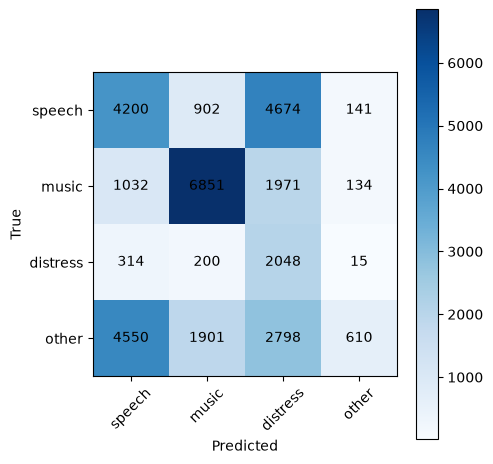

In [15]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=45)
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        ax.text(j, i, cm[i, j], ha='center', va='center')
plt.colorbar(im)
plt.tight_layout()
plt.show()

## Save the head (optional)

Just the small head — YAMNet itself doesn't need saving since you load it
fresh from TF Hub each time.

In [ ]:
head.save('distress_head.keras')

## Where this goes next

If per-class recall on `distress` looks reasonable, that's a strong signal
your labels and class scheme are workable. From here:

- **If recall is weak on `distress`** — go back to the data step. Pull more
  examples from AudioSet's `unbalanced` config, or check the confusion matrix
  above for which class it's being confused with.
- **For the actual ESP32 deployment** — this YAMNet+head combo isn't
  deployable as-is (YAMNet alone is a few MB). The next step is training a
  small CNN from scratch on mel-spectrograms, sized to fit the ESP32's memory
  budget. You can use this notebook's accuracy as your target ceiling, and
  even use YAMNet's predictions to help spot mislabeled clips in your `other`
  bucket before that training run.